In [1]:
import pandas as pd

df = pd.read_csv('creditcard.csv')  # Replace 'data.csv' with your actual data file
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print(df.shape)
df.info()

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

In [3]:
# Lo más importante de entrada: confirmar el desbalance
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# Paso 2 Inspección inicial enfocada en clasificación

In [4]:
# Estadísticas de Amount y Time, separadas por clase
df.groupby('Class')[['Time', 'Amount']].describe()

Time                                                       \
          count          mean           std    min      25%      50%   
Class                                                                  
0      284315.0  94838.202258  47484.015786    0.0  54230.0  84711.0   
1         492.0  80746.806911  47835.365138  406.0  41241.5  75568.5   

                             Amount                                            \
            75%       max     count        mean         std  min   25%    50%   
Class                                                                           
0      139333.0  172792.0  284315.0   88.291022  250.105092  0.0  5.65  22.00   
1      128483.0  170348.0     492.0  122.211321  256.683288  0.0  1.00   9.25   

                         
          75%       max  
Class                    
0       77.05  25691.16  
1      105.89   2125.87

C:\Users\uriel\AppData\Local\Temp\ipykernel_25524\447654841.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No fraude (0)', 'Fraude (1)'])


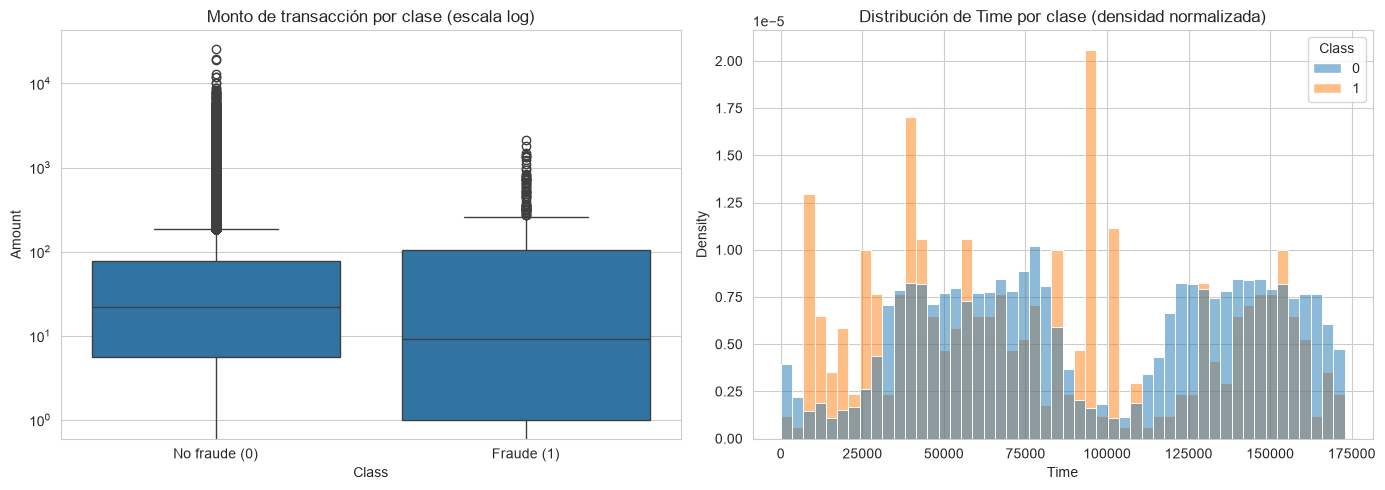

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de Amount por clase (con log para poder verlo, dado que hay muy pocos fraudes)
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Monto de transacción por clase (escala log)')
axes[0].set_xticklabels(['No fraude (0)', 'Fraude (1)'])

# Distribución de Time por clase
sns.histplot(data=df, x='Time', hue='Class', bins=50, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribución de Time por clase (densidad normalizada)')

plt.tight_layout()
plt.show()

In [6]:
# Duplicados — importante revisarlo antes de hacer el split
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 1081


# Tratamiento de duplicados

In [7]:
# Revisemos primero cuántos duplicados hay POR CLASE (importante, porque no queremos perder fraudes por accidente)
duplicados = df[df.duplicated(keep=False)]
print(duplicados['Class'].value_counts())

Class
0    1822
1      32
Name: count, dtype: int64


In [8]:
# Eliminamos duplicados (nos quedamos con la primera ocurrencia)
df = df.drop_duplicates()
print("Filas después de quitar duplicados:", df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Filas después de quitar duplicados: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


de los 1,081 duplicados, 32 eran fraudes reales. Al perderlos, bajamos de 492 a 473 fraudes (una caída de ~4%), pero el desbalance sigue prácticamente igual (0.167% vs. 0.172% original), así que no distorsiona el análisis. La decisión de eliminarlos fue correcta: eran filas idénticas en las 31 columnas (incluyendo las 28 componentes PCA), extremadamente improbable que ocurra por azar en variables continuas — son duplicados técnicos, no fraude repetido.

# Paso 3: Split estratificado

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # clave: mantiene la proporción 99.83% / 0.17% en ambos sets
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nProporción de clases en train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nProporción de clases en test:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (226980, 30)
Test shape: (56746, 30)

Proporción de clases en train:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Proporción de clases en test:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [10]:
# Conteo absoluto de fraudes en cada set — queremos ver que test tenga una cantidad razonable
print("Fraudes en train:", y_train.sum())
print("Fraudes en test:", y_test.sum())

Fraudes en train: 378
Fraudes en test: 95


Split perfecto: 226,980 en train (378 fraudes) y 56,746 en test (95 fraudes), con proporciones prácticamente idénticas en ambos sets (99.83% / 0.17%). El stratify funcionó exactamente como debía.

# Paso 4: Escalado + modelo baseline (sin balanceo)

In [11]:
from sklearn.preprocessing import StandardScaler

# Solo Time y Amount necesitan escalado — V1-V28 ya vienen normalizadas del PCA
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustamos el scaler SOLO con train (evita data leakage)
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

X_train_scaled[['Time', 'Amount']].describe()

,Time,Amount
count,2.269800e+05,2.269800e+05
mean,-1.522636e-16,7.487965e-17
std,1.000002e+00,1.000002e+00
min,-1.998400e+00,-3.596386e-01
25%,-8.561822e-01,-3.364866e-01
50%,-2.123526e-01,-2.697972e-01
75%,9.363191e-01,-4.287453e-02
max,1.640237e+00,7.962087e+01


Regresión Logística sin ningún tratamiento de desbalance, para tener el punto de comparación "ingenuo"

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

modelo_baseline = LogisticRegression(max_iter=1000, random_state=42)
modelo_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = modelo_baseline.predict(X_test_scaled)

print(classification_report(y_test, y_pred_baseline, target_names=['No fraude', 'Fraude']))

              precision    recall  f1-score   support

   No fraude       1.00      1.00      1.00     56651
      Fraude       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



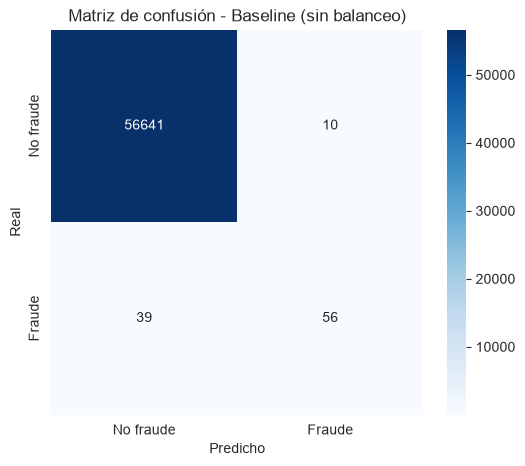

In [13]:
import numpy as np

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No fraude', 'Fraude'], yticklabels=['No fraude', 'Fraude'])
plt.title('Matriz de confusión - Baseline (sin balanceo)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Paso 5: Tratamiento del desbalance


In [14]:
modelo_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = modelo_balanced.predict(X_test_scaled)

print("=== Con class_weight='balanced' ===")
print(classification_report(y_test, y_pred_balanced, target_names=['No fraude', 'Fraude']))

=== Con class_weight='balanced' ===
              precision    recall  f1-score   support

   No fraude       1.00      0.98      0.99     56651
      Fraude       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [ ]:
!pip install imbalanced-learn

In [17]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Antes de SMOTE:", y_train.value_counts().to_dict())
print("Después de SMOTE:", y_train_smote.value_counts().to_dict())

modelo_smote = LogisticRegression(max_iter=1000, random_state=42)
modelo_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = modelo_smote.predict(X_test_scaled)

print("\n=== Con SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['No fraude', 'Fraude']))

Antes de SMOTE: {0: 226602, 1: 378}
Después de SMOTE: {0: 226602, 1: 226602}

=== Con SMOTE ===
              precision    recall  f1-score   support

   No fraude       1.00      0.97      0.99     56651
      Fraude       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



trade-off precision-recall

# Paso 6: Random Forest + curva Precision-Recall

In [18]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)

y_pred_rf = modelo_rf.predict(X_test_scaled)

print("=== Random Forest (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_rf, target_names=['No fraude', 'Fraude']))

=== Random Forest (class_weight='balanced') ===
              precision    recall  f1-score   support

   No fraude       1.00      1.00      1.00     56651
      Fraude       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



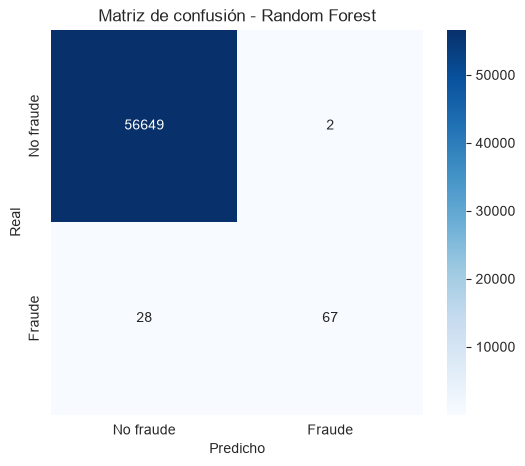

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No fraude', 'Fraude'], yticklabels=['No fraude', 'Fraude'])
plt.title('Matriz de confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

curva Precision-Recall completa

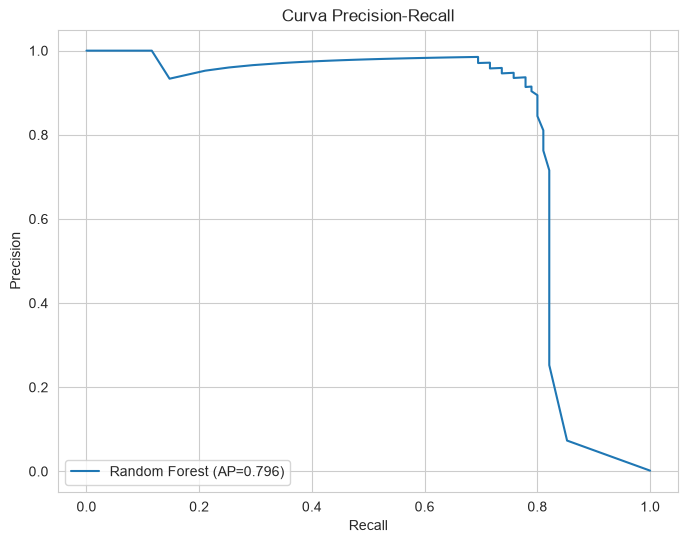

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

probs_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs_rf)
ap_score = average_precision_score(y_test, probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (AP={ap_score:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

# Paso 7: Ajustar el umbral de decisión

In [23]:
import pandas as pd

# Buscamos el umbral que maximiza F1 (razonable como punto de partida)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
mejor_idx = f1_scores.argmax()
mejor_umbral = thresholds[mejor_idx]

print(f"Mejor umbral (max F1): {mejor_umbral:.3f}")
print(f"Precision en ese punto: {precision[mejor_idx]:.3f}")
print(f"Recall en ese punto: {recall[mejor_idx]:.3f}")
print(f"F1 en ese punto: {f1_scores[mejor_idx]:.3f}")

Mejor umbral (max F1): 0.220
Precision en ese punto: 0.937
Recall en ese punto: 0.779
F1 en ese punto: 0.851


In [24]:
# Aplicamos ese umbral en vez del 0.5 por defecto
y_pred_umbral_ajustado = (probs_rf >= mejor_umbral).astype(int)

print("=== Random Forest con umbral ajustado ===")
print(classification_report(y_test, y_pred_umbral_ajustado, target_names=['No fraude', 'Fraude']))

=== Random Forest con umbral ajustado ===
              precision    recall  f1-score   support

   No fraude       1.00      1.00      1.00     56651
      Fraude       0.94      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [25]:
# Comparación visual: dos escenarios de negocio distintos
# Escenario A: priorizar recall (detectar más fraude, aceptar más falsas alarmas) -> ej. umbral bajo
# Escenario B: priorizar precision (menos falsas alarmas, aceptar perder algo de fraude) -> ej. umbral alto

for umbral_ejemplo in [0.2, 0.5, 0.8]:
    pred_ejemplo = (probs_rf >= umbral_ejemplo).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, pred_ejemplo)
    r = recall_score(y_test, pred_ejemplo)
    f1 = f1_score(y_test, pred_ejemplo)
    print(f"Umbral={umbral_ejemplo}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

Umbral=0.2: Precision=0.914, Recall=0.779, F1=0.841
Umbral=0.5: Precision=0.971, Recall=0.705, F1=0.817
Umbral=0.8: Precision=0.980, Recall=0.526, F1=0.685


# Paso 8: Feature importance 

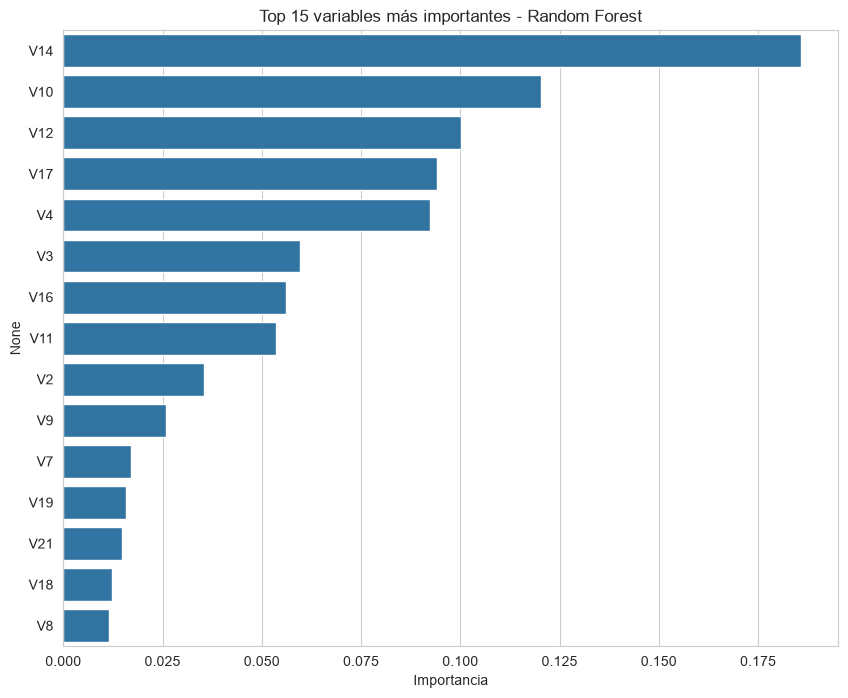

V14    0.185906
V10    0.120391
V12    0.100258
V17    0.094048
V4     0.092252
V3     0.059660
V16    0.056156
V11    0.053584
V2     0.035558
V9     0.025836
dtype: float64


In [26]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.head(15).values, y=importancias.head(15).index)
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.show()

print(importancias.head(10))

# Paso 9 XGBoost

In [ ]:
!pip install xgboost

In [28]:

from xgboost import XGBClassifier

# scale_pos_weight es el equivalente de class_weight en XGBoost:
# ratio negativos/positivos, para compensar el desbalance
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight sugerido: {ratio:.1f}")

modelo_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='aucpr',  # métrica correcta para desbalance (área bajo curva precision-recall)
    n_jobs=-1
)

modelo_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = modelo_xgb.predict(X_test_scaled)

print("=== XGBoost (umbral 0.5) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No fraude', 'Fraude']))

scale_pos_weight sugerido: 599.5
=== XGBoost (umbral 0.5) ===
              precision    recall  f1-score   support

   No fraude       1.00      1.00      1.00     56651
      Fraude       0.97      0.78      0.87        95

    accuracy                           1.00     56746
   macro avg       0.99      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



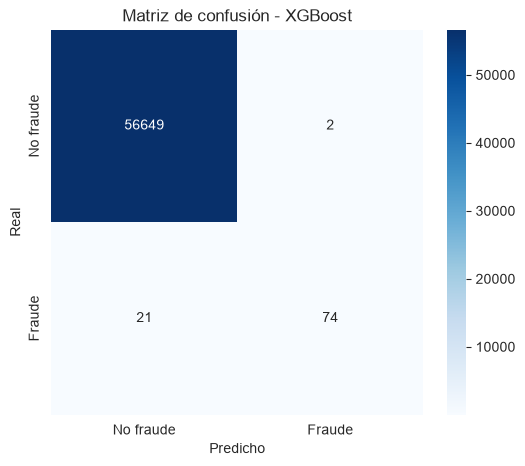

In [29]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No fraude', 'Fraude'], yticklabels=['No fraude', 'Fraude'])
plt.title('Matriz de confusión - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

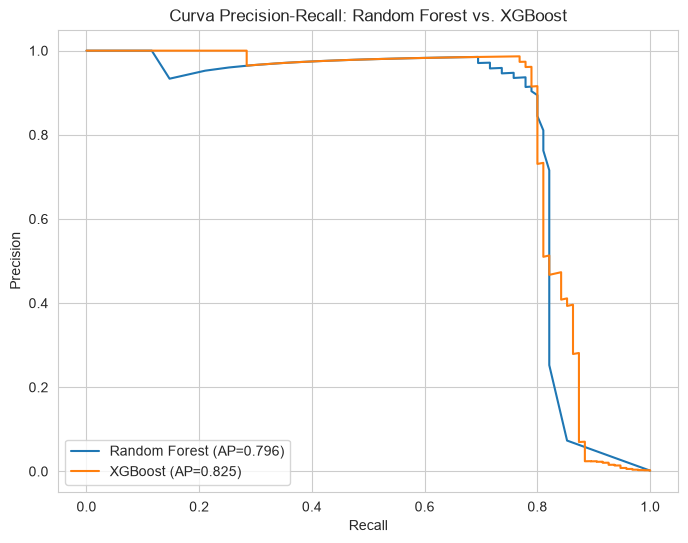

In [30]:
probs_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1]
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, probs_xgb)
ap_score_xgb = average_precision_score(y_test, probs_xgb)

# Comparamos ambas curvas en la misma gráfica
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (AP={ap_score:.3f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall: Random Forest vs. XGBoost')
plt.legend()
plt.show()

In [31]:
# Mejor umbral para XGBoost (máximo F1), igual que hicimos con RF
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-10)
mejor_idx_xgb = f1_scores_xgb.argmax()
mejor_umbral_xgb = thresholds_xgb[mejor_idx_xgb]

y_pred_xgb_ajustado = (probs_xgb >= mejor_umbral_xgb).astype(int)

print(f"Mejor umbral XGBoost (max F1): {mejor_umbral_xgb:.3f}")
print("\n=== XGBoost con umbral ajustado ===")
print(classification_report(y_test, y_pred_xgb_ajustado, target_names=['No fraude', 'Fraude']))


Mejor umbral XGBoost (max F1): 0.478

=== XGBoost con umbral ajustado ===
              precision    recall  f1-score   support

   No fraude       1.00      1.00      1.00     56651
      Fraude       0.96      0.79      0.87        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



# Paso 10 Conclusiones

## Conclusiones

Este proyecto aborda la detección de fraude en transacciones de tarjetas de crédito 
(dataset Kaggle mlg-ulb, 284,807 transacciones europeas de septiembre 2013), con foco 
en el manejo correcto de clases extremadamente desbalanceadas (0.17% de fraude).

### Hallazgos principales

**1. Accuracy es una métrica engañosa con desbalance extremo**
Un modelo baseline sin ningún tratamiento alcanza 99.83% de accuracy prediciendo casi 
siempre "no fraude" — pero solo detecta el 59% de los fraudes reales (recall).

**2. El balanceo de clases mejora el recall a costa de la precisión**
`class_weight='balanced'` y SMOTE elevaron el recall de 0.59 a 0.87, pero hundieron 
la precisión a 0.05-0.06 (95% de falsas alarmas) — un trade-off inviable para producción 
con Regresión Logística.

**3. Los modelos de árboles superan claramente a la regresión logística**
Random Forest (F1=0.851, AP=0.796) y XGBoost (F1=0.87, AP=0.825) manejan el desbalance 
de forma nativa, sin necesitar SMOTE. XGBoost fue el mejor modelo del proyecto, 
detectando 74 de 95 fraudes (78%) con solo 2-3 falsos positivos en 56,651 transacciones 
legítimas — aunque su ventaja sobre Random Forest fue moderada (~2 puntos de F1), no 
dramática.

**4. La elección de umbral debe ser una decisión de negocio, no técnica**
Se compararon distintos umbrales de decisión, mostrando que el mismo modelo puede 
priorizar detectar más fraude (mayor recall) o minimizar falsas alarmas (mayor precisión) 
dependiendo del costo real de cada tipo de error para el negocio.

**5. Las variables PCA superan a Time y Amount en poder predictivo**
Las 5 variables más importantes para Random Forest (V14, V10, V12, V17, V4) son todas 
componentes PCA; ni Time ni Amount aparecen en el top 15.

### Consideraciones metodológicas
- Split estratificado para preservar la proporción de clases en train/test.
- Escalado (`StandardScaler`) ajustado solo con datos de entrenamiento, para evitar 
  data leakage.
- SMOTE aplicado únicamente sobre el set de entrenamiento; el set de test se mantuvo 
  con la proporción real de fraude (0.17%) para una evaluación honesta.
- Se identificaron y eliminaron 1,081 filas duplicadas (32 de ellas fraudes) antes 
  del split.

### Posibles siguientes pasos
- Calibración de probabilidades (`CalibratedClassifierCV`) si se necesitan probabilidades 
  interpretables, no solo un umbral de decisión.
- Análisis de costo-beneficio explícito (asignar valor monetario a falsos positivos 
  y falsos negativos) para elegir el umbral óptimo de forma cuantitativa, no solo por F1.
- Explorar modelos de detección de anomalías (Isolation Forest, autoencoders) como 
  enfoque no supervisado complementario.